# Import Required Libraries

In [66]:
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully.")

All libraries imported successfully.


# Load the Dataset

In [2]:
# File path
file_path = "Original File.xlsx"

# Display all sheet names
excel_file = pd.ExcelFile(file_path)

print("Available Sheets:")
print(excel_file.sheet_names)

# Load the OriginalDataset sheet
df = pd.read_excel(file_path, sheet_name="OriginalDataset")

print("\nDataset Loaded Successfully!")

# Display first 5 rows
df.head()

Available Sheets:
['OriginalDataset']

Dataset Loaded Successfully!


,product_id,product_name,user_id,user_age_range,user_gender,review_title,review_description,review_date,Month,product_rating,...,packaging_quality,product_price,product_discount,spent_time,CTR (Click-Through Rate),location,product_type,sentiment,user_avg_rating,product_avg_rating
0,238,Big Toner,1611,35-44,Male,Disappointed with Big Toner,One of the best products I’ve used recently. B...,2024-04-16,Apr,2,...,Eco-friendly,7.38,No,44,0.69,"Cape Town, South Africa",Skin Care,Negative,2.86,2.99
1,248,Science Cream,1414,55+,Male,Trying out Science Cream,Science Cream caused some irritation on my ski...,2023-06-23,Jun,1,...,Portable,12.33,No,94,0.54,"Paris, France",Skin Care,Negative,2.66,2.99
2,237,Officer Shampoo,1657,55+,Female,Would buy Officer Shampoo again!,One of the best products I’ve used recently. O...,2024-01-23,Jan,2,...,Portable,22.71,No,41,0.57,"New York, USA",Hair Treatment,Negative,2.92,3.05
3,283,Green Serum,1122,55+,Female,Would buy Green Serum again!,I tried the Green Serum and it worked quite we...,2025-03-05,Mar,2,...,Eco-friendly,34.45,No,143,0.29,"Mumbai, India",Skin Care,Negative,2.91,2.96
4,230,Clear Lipstick,1354,18-24,Female,Disappointed with Clear Lipstick,Clear Lipstick didn’t work as I hoped. Maybe i...,2025-02-25,Feb,2,...,Satisfying,9.45,5%,85,0.55,"São Paulo, Brazil",Makeup,Negative,3.19,2.92


# Dataset Inspection

In [3]:
print("="*60)
print("DATASET OVERVIEW")
print("="*60)

# Shape of the dataset
print(f"\nDataset Shape: {df.shape}")
print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

# Column names
print("\nColumn Names:")
for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

# Data types
print("\nData Types:")
print(df.dtypes)

# Dataset information
print("\nDataset Information:")
df.info()

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Duplicate records
print("\nDuplicate Rows:")
print(df.duplicated().sum())

# Statistical summary (Numerical)
print("\nStatistical Summary (Numerical Features):")
print(df.describe())

# Statistical summary (Categorical)
print("\nStatistical Summary (Categorical Features):")
print(df.describe(include='object'))

DATASET OVERVIEW

Dataset Shape: (50000, 21)
Number of Rows    : 50000
Number of Columns : 21

Column Names:
1. product_id
2. product_name
3. user_id
4. user_age_range
5. user_gender
6. review_title
7. review_description
8. review_date
9. Month
10. product_rating
11. Recommendation
12. packaging_quality
13. product_price
14. product_discount
15. spent_time
16.  CTR (Click-Through Rate)
17. location
18. product_type
19. sentiment
20. user_avg_rating
21. product_avg_rating

Data Types:
product_id                            int64
product_name                         object
user_id                               int64
user_age_range                       object
user_gender                          object
review_title                         object
review_description                   object
review_date                  datetime64[ns]
Month                                object
product_rating                        int64
Recommendation                       object
packaging_quality          

# Data Preprocessing

In [6]:
print("="*60)
print("DATA PREPROCESSING")
print("="*60)

# Make a copy of the original dataset
df_processed = df.copy()

# Drop unnecessary columns
# These columns are not useful for training the ML models
columns_to_drop = [
    'product_id',
    'user_id',
    'review_title',
    'review_description',
    'review_date'
]

df_processed.drop(columns=columns_to_drop, inplace=True)

print("Unnecessary columns removed.")

# Check remaining columns

print("\nRemaining Columns:")
print(df_processed.columns.tolist())

# Encode Target Variable
# Recommendation:
# Yes = 1
# No = 0
df_processed['Recommendation'] = df_processed['Recommendation'].map({
    'Yes':1,
    'No':0
})

print("\nTarget variable encoded.")

# Encode all categorical features

label_encoder = LabelEncoder()

categorical_columns = df_processed.select_dtypes(include='object').columns

print("\nEncoding Columns:")

for col in categorical_columns:
    if col != 'Recommendation':
        df_processed[col] = label_encoder.fit_transform(df_processed[col])
        print(f". {col}")

print("\nAll categorical variables encoded.")

# Check processed dataset
print("\nProcessed Dataset Shape:")
print(df_processed.shape)

print("\nData Types After Encoding:")
print(df_processed.dtypes)

print("\nFirst 5 Rows:")
display(df_processed.head())

DATA PREPROCESSING
Unnecessary columns removed.

Remaining Columns:
['product_name', 'user_age_range', 'user_gender', 'Month', 'product_rating', 'Recommendation', 'packaging_quality', 'product_price', 'product_discount', 'spent_time', ' CTR (Click-Through Rate)', 'location', 'product_type', 'sentiment', 'user_avg_rating', 'product_avg_rating']

Target variable encoded.

Encoding Columns:
. product_name
. user_age_range
. user_gender
. Month
. packaging_quality
. product_discount
. location
. product_type
. sentiment

All categorical variables encoded.

Processed Dataset Shape:
(50000, 16)

Data Types After Encoding:
product_name                   int64
user_age_range                 int64
user_gender                    int64
Month                          int64
product_rating                 int64
Recommendation                 int64
packaging_quality              int64
product_price                float64
product_discount               int64
spent_time                     int64
 CTR (

,product_name,user_age_range,user_gender,Month,product_rating,Recommendation,packaging_quality,product_price,product_discount,spent_time,CTR (Click-Through Rate),location,product_type,sentiment,user_avg_rating,product_avg_rating
0,9,2,1,0,2,0,1,7.38,2,44,0.69,1,2,0,2.86,2.99
1,68,4,1,6,1,0,3,12.33,2,94,0.54,5,2,0,2.66,2.99
2,55,4,0,4,2,0,3,22.71,2,41,0.57,4,0,0,2.92,3.05
3,36,4,0,7,2,0,1,34.45,2,143,0.29,3,2,0,2.91,2.96
4,17,0,0,3,2,0,4,9.45,1,85,0.55,7,1,0,3.19,2.92


# Exploratory Data Analysis (EDA)

# Recommendation Distribution

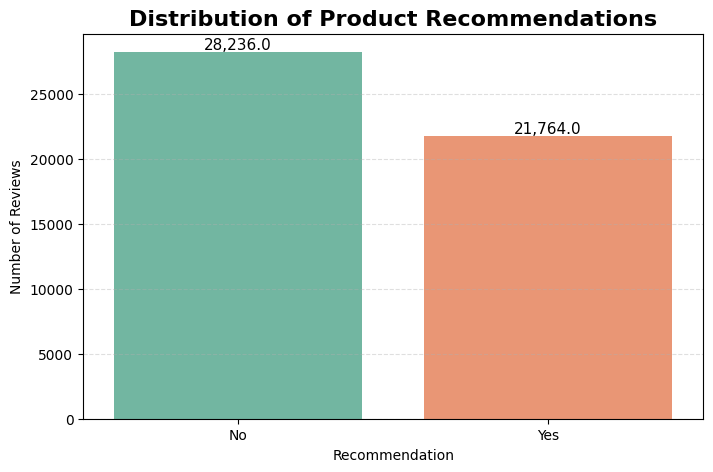

In [7]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='Recommendation',
    data=df,
    palette='Set2'
)

plt.title('Distribution of Product Recommendations', fontsize=16, weight='bold')
plt.xlabel('Recommendation')
plt.ylabel('Number of Reviews')

for p in ax.patches:
    ax.annotate(f'{p.get_height():,}',
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center',
                va='bottom',
                fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

# Sentiment Distribution

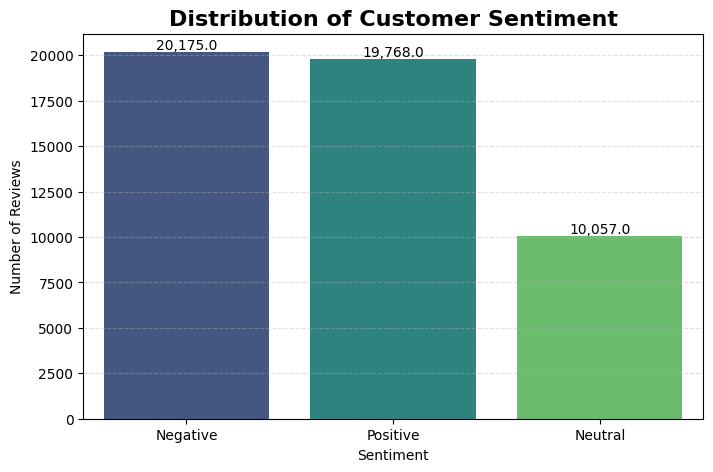

In [8]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='sentiment',
    data=df,
    palette='viridis',
    order=df['sentiment'].value_counts().index
)

plt.title('Distribution of Customer Sentiment', fontsize=16, weight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')

for p in ax.patches:
    ax.annotate(f'{p.get_height():,}',
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center',
                va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

# Product Rating Distribution

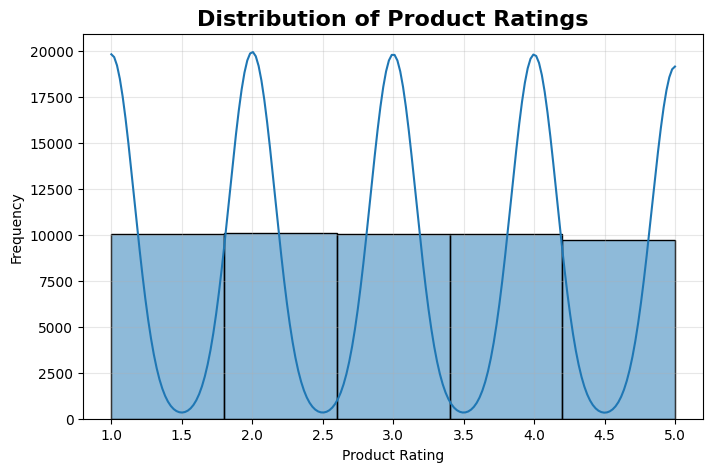

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='product_rating',
    bins=5,
    kde=True
)

plt.title('Distribution of Product Ratings', fontsize=16, weight='bold')
plt.xlabel('Product Rating')
plt.ylabel('Frequency')

plt.grid(alpha=0.3)

plt.show()

# CTR by Product Type

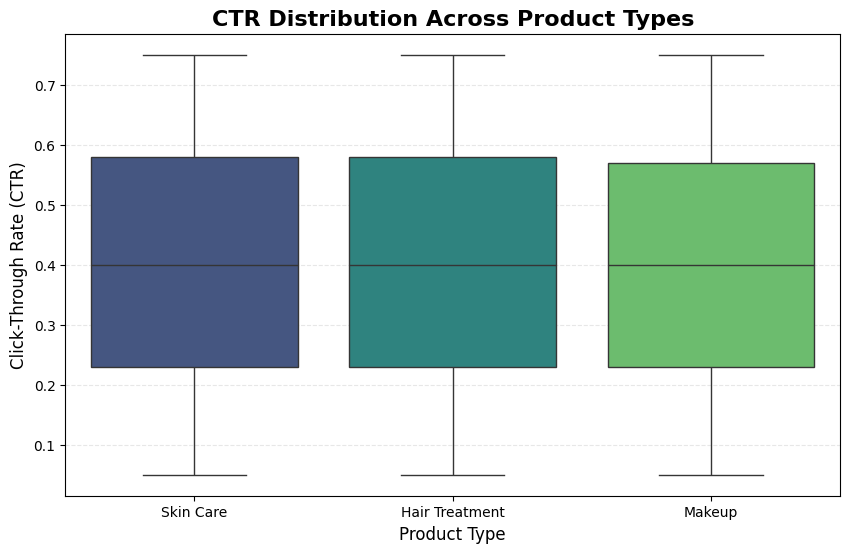

In [15]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='product_type',
    y=' CTR (Click-Through Rate)',
    palette='viridis'
)

plt.title('CTR Distribution Across Product Types',
          fontsize=16,
          weight='bold')

plt.xlabel('Product Type', fontsize=12)
plt.ylabel('Click-Through Rate (CTR)', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

# Correlation Heatmap

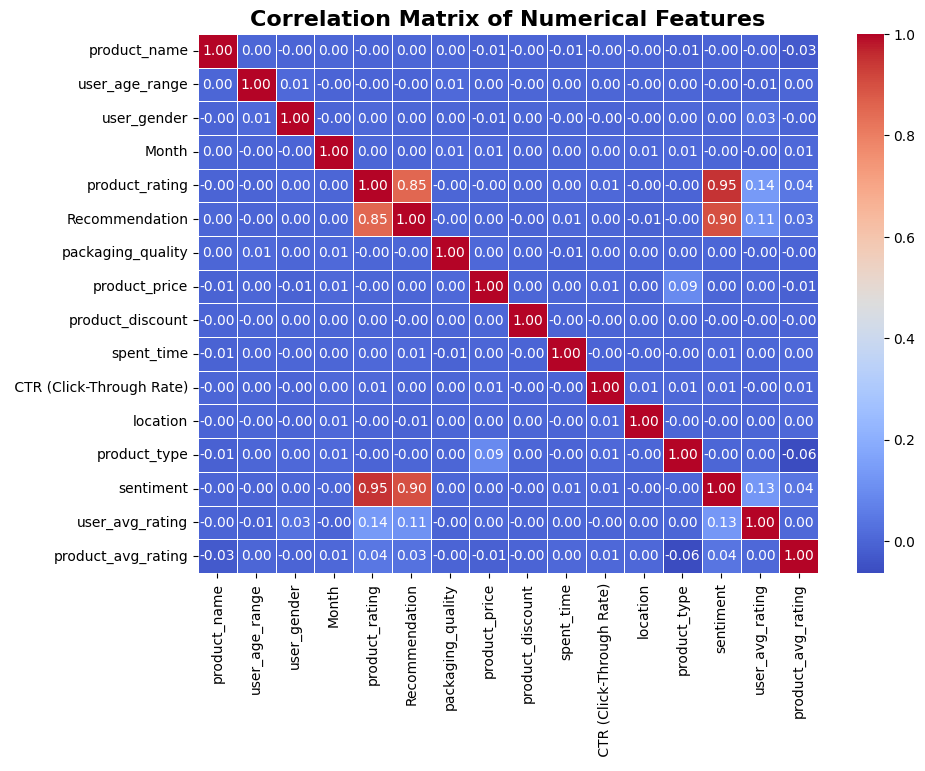

In [11]:
numeric_df = df_processed.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(10,7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Matrix of Numerical Features', fontsize=16, weight='bold')

plt.show()

# Feature Selection

In [16]:
print("="*60)
print("FEATURE SELECTION")
print("="*60)

# Separate Features (X) and Target Variable (y)

X = df_processed.drop(columns=['Recommendation'])

y = df_processed['Recommendation']

print("\nFeature Matrix (X) Shape :", X.shape)
print("Target Variable (y) Shape :", y.shape)

print("\nFeature Columns:")
for i, column in enumerate(X.columns, start=1):
    print(f"{i}. {column}")

print("\nTarget Variable:")
print(y.name)

FEATURE SELECTION

Feature Matrix (X) Shape : (50000, 15)
Target Variable (y) Shape : (50000,)

Feature Columns:
1. product_name
2. user_age_range
3. user_gender
4. Month
5. product_rating
6. packaging_quality
7. product_price
8. product_discount
9. spent_time
10.  CTR (Click-Through Rate)
11. location
12. product_type
13. sentiment
14. user_avg_rating
15. product_avg_rating

Target Variable:
Recommendation


# TRAIN TEST SPLIT

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("="*60)
print("TRAIN TEST SPLIT")
print("="*60)

print(f"Training Features : {X_train.shape}")
print(f"Testing Features  : {X_test.shape}")

print(f"Training Labels   : {y_train.shape}")
print(f"Testing Labels    : {y_test.shape}")

TRAIN TEST SPLIT
Training Features : (40000, 15)
Testing Features  : (10000, 15)
Training Labels   : (40000,)
Testing Labels    : (10000,)


# FEATURE SCALING

In [20]:
# Numerical columns only
numerical_columns = [
    'product_rating',
    'product_price',
    'spent_time',
    ' CTR (Click-Through Rate)',
    'user_avg_rating',
    'product_avg_rating'
]

# Create copies
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Initialize scaler
scaler = StandardScaler()

# Scale only numerical columns
X_train_scaled[numerical_columns] = scaler.fit_transform(
    X_train[numerical_columns]
)

X_test_scaled[numerical_columns] = scaler.transform(
    X_test[numerical_columns]
)

print("="*60)
print("FEATURE SCALING COMPLETED")
print("="*60)

print("\nScaled Numerical Features:")
for col in numerical_columns:
    print(f". {col}")

print("\nTraining Dataset Shape :", X_train_scaled.shape)
print("Testing Dataset Shape  :", X_test_scaled.shape)

print("\nFirst Five Rows of Scaled Training Data:")
display(X_train_scaled.head())

FEATURE SCALING COMPLETED

Scaled Numerical Features:
. product_rating
. product_price
. spent_time
.  CTR (Click-Through Rate)
. user_avg_rating
. product_avg_rating

Training Dataset Shape : (40000, 15)
Testing Dataset Shape  : (10000, 15)

First Five Rows of Scaled Training Data:


,product_name,user_age_range,user_gender,Month,product_rating,packaging_quality,product_price,product_discount,spent_time,CTR (Click-Through Rate),location,product_type,sentiment,user_avg_rating,product_avg_rating
16294,93,2,0,3,0.717156,3,0.536209,1,0.439696,1.025049,9,1,2,0.280627,-0.415673
36678,83,3,0,0,0.007785,0,1.232799,0,1.556822,-0.749778,8,2,1,0.486660,0.080579
19977,64,3,1,2,0.717156,1,0.003337,2,0.368390,0.926448,1,2,2,0.280627,-0.084838
23347,65,1,1,10,-0.701585,2,-0.972678,0,0.213894,-0.207470,5,2,0,-0.028424,-1.408178
5499,41,2,0,6,0.717156,2,-1.607874,2,-1.069612,0.236237,2,2,2,-1.779708,-1.077343


# Machine Learning Models

# LOGISTIC REGRESSION

Logistic Regression Model Trained Successfully

Model Performance
----------------------------------------
Accuracy : 0.9571
Precision: 1.0000
Recall   : 0.9014
F1-Score : 0.9482
ROC-AUC  : 0.9864


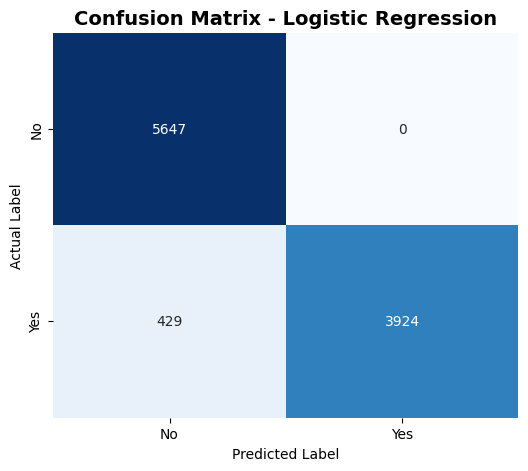


Classification Report
----------------------------------------
              precision    recall  f1-score   support

           0       0.93      1.00      0.96      5647
           1       1.00      0.90      0.95      4353

    accuracy                           0.96     10000
   macro avg       0.96      0.95      0.96     10000
weighted avg       0.96      0.96      0.96     10000



In [22]:
# Create Model
log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Train Model
log_model.fit(X_train_scaled, y_train)

print("Logistic Regression Model Trained Successfully")

# Prediction
y_pred_log = log_model.predict(X_test_scaled)

# Probability Prediction
y_prob_log = log_model.predict_proba(X_test_scaled)[:,1]

# Evaluation Metrics
log_accuracy = accuracy_score(y_test, y_pred_log)
log_precision = precision_score(y_test, y_pred_log)
log_recall = recall_score(y_test, y_pred_log)
log_f1 = f1_score(y_test, y_pred_log)
log_auc = roc_auc_score(y_test, y_prob_log)

print("\nModel Performance")
print("-"*40)

print(f"Accuracy : {log_accuracy:.4f}")
print(f"Precision: {log_precision:.4f}")
print(f"Recall   : {log_recall:.4f}")
print(f"F1-Score : {log_f1:.4f}")
print(f"ROC-AUC  : {log_auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['No','Yes'],
    yticklabels=['No','Yes']
)

plt.title("Confusion Matrix - Logistic Regression",
          fontsize=14,
          weight='bold')

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

# Classification Report
print("\nClassification Report")
print("-"*40)

print(classification_report(y_test, y_pred_log))

# DECISION TREE

Decision Tree Model Trained Successfully

Model Performance
----------------------------------------
Accuracy : 0.9549
Precision: 0.9912
Recall   : 0.9044
F1-Score : 0.9458
ROC-AUC  : 0.9852


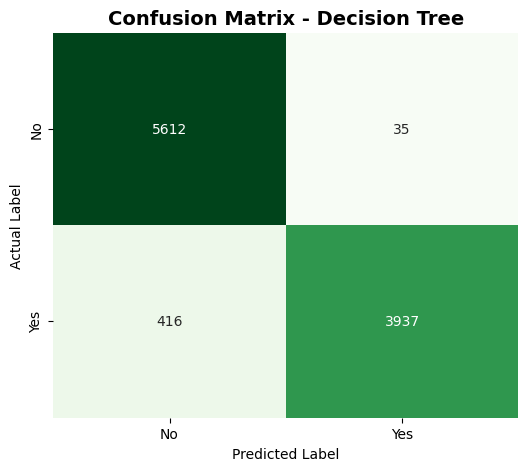


Classification Report
----------------------------------------
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5647
           1       0.99      0.90      0.95      4353

    accuracy                           0.95     10000
   macro avg       0.96      0.95      0.95     10000
weighted avg       0.96      0.95      0.95     10000



In [24]:
# Create Decision Tree Model
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5
)

# Train Model
dt_model.fit(X_train_scaled, y_train)

print("Decision Tree Model Trained Successfully")

# Prediction
y_pred_dt = dt_model.predict(X_test_scaled)

# Probability Prediction
y_prob_dt = dt_model.predict_proba(X_test_scaled)[:,1]

# Evaluation Metrics
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)
dt_auc = roc_auc_score(y_test, y_prob_dt)

print("\nModel Performance")
print("-"*40)

print(f"Accuracy : {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall   : {dt_recall:.4f}")
print(f"F1-Score : {dt_f1:.4f}")
print(f"ROC-AUC  : {dt_auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    cbar=False,
    xticklabels=['No', 'Yes'],
    yticklabels=['No', 'Yes']
)

plt.title("Confusion Matrix - Decision Tree",
          fontsize=14,
          weight='bold')

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

# Classification Report
print("\nClassification Report")
print("-"*40)

print(classification_report(y_test, y_pred_dt))

# RANDOM FOREST

Random Forest Model Trained Successfully

Model Performance
----------------------------------------
Accuracy : 0.9571
Precision: 1.0000
Recall   : 0.9014
F1-Score : 0.9482
ROC-AUC  : 0.9837


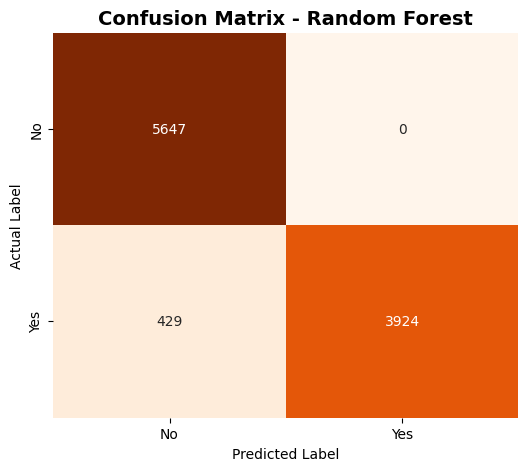


Classification Report
----------------------------------------
              precision    recall  f1-score   support

           0       0.93      1.00      0.96      5647
           1       1.00      0.90      0.95      4353

    accuracy                           0.96     10000
   macro avg       0.96      0.95      0.96     10000
weighted avg       0.96      0.96      0.96     10000



In [33]:
# Create Random Forest Model
rf_model = RandomForestClassifier(
    n_estimators=20,
    max_depth=3,
    min_samples_split=30,
    min_samples_leaf=15,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

# Train Model
rf_model.fit(X_train_scaled, y_train)

print("Random Forest Model Trained Successfully")

# Prediction
y_pred_rf = rf_model.predict(X_test_scaled)

# Probability Prediction
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation Metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)

print("\nModel Performance")
print("-"*40)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Oranges',
    cbar=False,
    xticklabels=['No', 'Yes'],
    yticklabels=['No', 'Yes']
)

plt.title("Confusion Matrix - Random Forest",
          fontsize=14,
          weight='bold')

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

# Classification Report
print("\nClassification Report")
print("-"*40)

print(classification_report(y_test, y_pred_rf))

# XGBOOST

XGBoost Model Trained Successfully

Model Performance
----------------------------------------
Accuracy : 0.9569
Precision: 0.9977
Recall   : 0.9031
F1-Score : 0.9480
ROC-AUC  : 0.9861


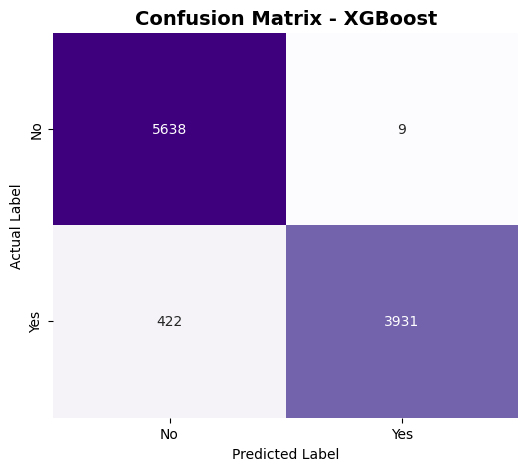


Classification Report
----------------------------------------
              precision    recall  f1-score   support

           0       0.93      1.00      0.96      5647
           1       1.00      0.90      0.95      4353

    accuracy                           0.96     10000
   macro avg       0.96      0.95      0.96     10000
weighted avg       0.96      0.96      0.96     10000



In [28]:
# Create XGBoost Model
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

# Train Model
xgb_model.fit(X_train_scaled, y_train)

print("XGBoost Model Trained Successfully")

# Prediction
y_pred_xgb = xgb_model.predict(X_test_scaled)

# Probability Prediction
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:,1]

# Evaluation Metrics
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_auc = roc_auc_score(y_test, y_prob_xgb)

print("\nModel Performance")
print("-"*40)

print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1-Score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    cbar=False,
    xticklabels=['No', 'Yes'],
    yticklabels=['No', 'Yes']
)

plt.title(
    "Confusion Matrix - XGBoost",
    fontsize=14,
    weight='bold'
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

# Classification Report
print("\nClassification Report")
print("-"*40)

print(classification_report(y_test, y_pred_xgb))

# MODEL COMPARISON

In [34]:
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy': [
        log_accuracy,
        dt_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    'Precision': [
        log_precision,
        dt_precision,
        rf_precision,
        xgb_precision
    ],
    'Recall': [
        log_recall,
        dt_recall,
        rf_recall,
        xgb_recall
    ],
    'F1-Score': [
        log_f1,
        dt_f1,
        rf_f1,
        xgb_f1
    ],
    'ROC-AUC': [
        log_auc,
        dt_auc,
        rf_auc,
        xgb_auc
    ]
})

comparison = comparison.round(4)

print("="*70)
print("MODEL PERFORMANCE COMPARISON")
print("="*70)

display(comparison)

MODEL PERFORMANCE COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.9571,1.0000,0.9014,0.9482,0.9864
1,Decision Tree,0.9549,0.9912,0.9044,0.9458,0.9852
2,Random Forest,0.9571,1.0000,0.9014,0.9482,0.9837
3,XGBoost,0.9569,0.9977,0.9031,0.9480,0.9861


In [35]:
best_model = comparison.loc[
    comparison['Accuracy'].idxmax()
]

print("="*60)
print("BEST PERFORMING MODEL")
print("="*60)

print(best_model)

BEST PERFORMING MODEL
Model        Logistic Regression
Accuracy                  0.9571
Precision                    1.0
Recall                    0.9014
F1-Score                  0.9482
ROC-AUC                   0.9864
Name: 0, dtype: object


# ACCURACY COMPARISON

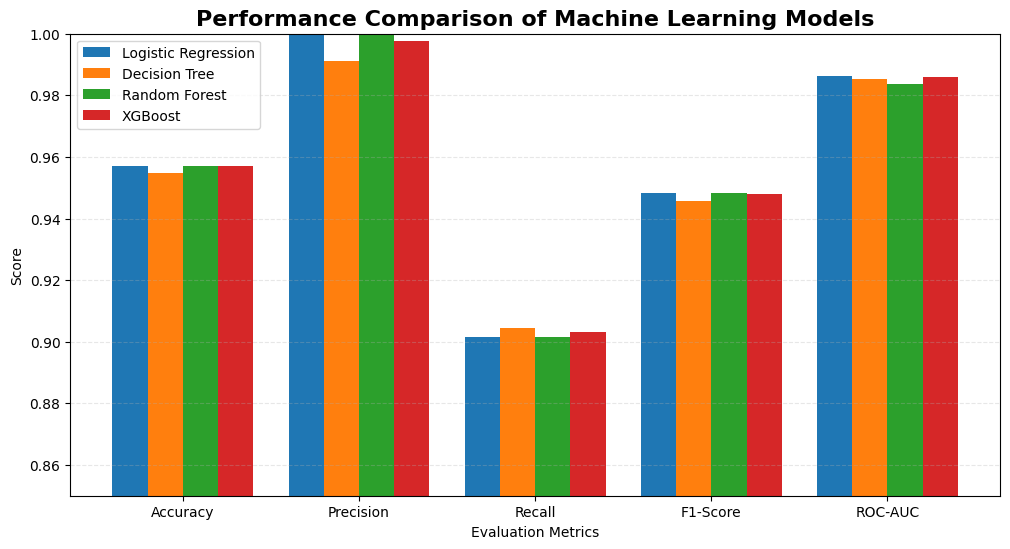

In [38]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

x = np.arange(len(metrics))
width = 0.2

plt.figure(figsize=(12,6))

plt.bar(x - 1.5*width,
        comparison.loc[0, metrics],
        width,
        label='Logistic Regression')

plt.bar(x - 0.5*width,
        comparison.loc[1, metrics],
        width,
        label='Decision Tree')

plt.bar(x + 0.5*width,
        comparison.loc[2, metrics],
        width,
        label='Random Forest')

plt.bar(x + 1.5*width,
        comparison.loc[3, metrics],
        width,
        label='XGBoost')

plt.xticks(x, metrics)

plt.ylim(0.85, 1.00)

plt.ylabel("Score")
plt.xlabel("Evaluation Metrics")

plt.title("Performance Comparison of Machine Learning Models",
          fontsize=16,
          weight='bold')

plt.legend()

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

# ROC CURVE COMPARISON

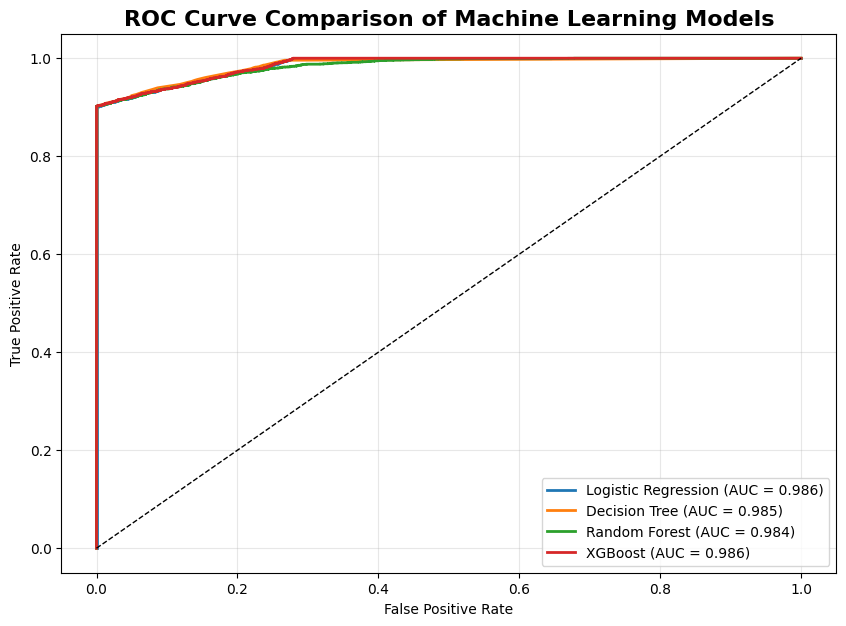

In [45]:
plt.figure(figsize=(10,7))

# Logistic Regression
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
plt.plot(fpr_log, tpr_log,
         linewidth=2,
         label=f'Logistic Regression (AUC = {log_auc:.3f})')

# Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
plt.plot(fpr_dt, tpr_dt,
         linewidth=2,
         label=f'Decision Tree (AUC = {dt_auc:.3f})')

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf,
         linewidth=2,
         label=f'Random Forest (AUC = {rf_auc:.3f})')

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
plt.plot(fpr_xgb, tpr_xgb,
         linewidth=2,
         label=f'XGBoost (AUC = {xgb_auc:.3f})')

# Random classifier
plt.plot([0,1],[0,1],'k--',linewidth=1)

plt.title("ROC Curve Comparison of Machine Learning Models",
          fontsize=16,
          weight='bold')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend(loc='lower right')

plt.grid(alpha=0.3)

plt.show()

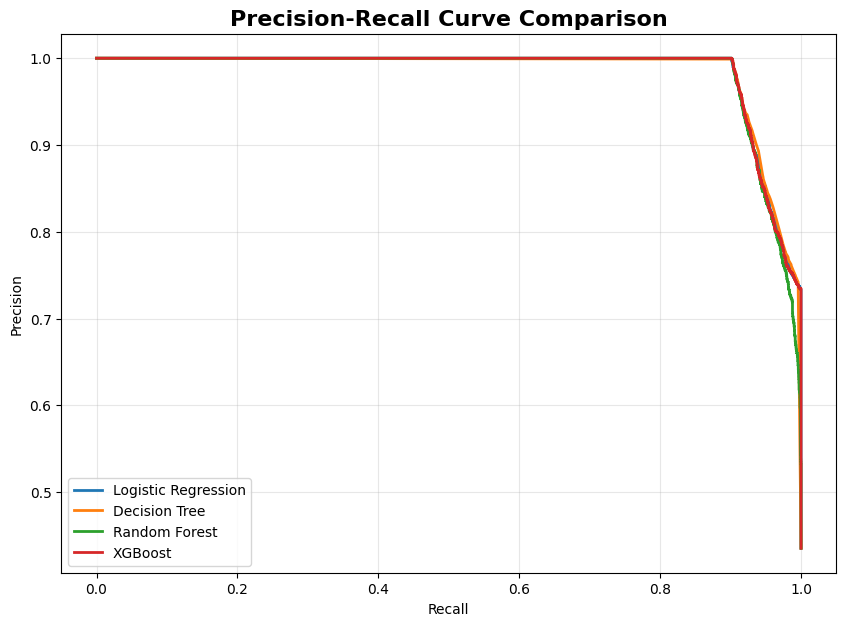

In [46]:
plt.figure(figsize=(10,7))

# Logistic Regression
precision_log, recall_log, _ = precision_recall_curve(
    y_test,
    y_prob_log
)

plt.plot(recall_log,
         precision_log,
         linewidth=2,
         label='Logistic Regression')

# Decision Tree
precision_dt, recall_dt, _ = precision_recall_curve(
    y_test,
    y_prob_dt
)

plt.plot(recall_dt,
         precision_dt,
         linewidth=2,
         label='Decision Tree')

# Random Forest
precision_rf, recall_rf, _ = precision_recall_curve(
    y_test,
    y_prob_rf
)

plt.plot(recall_rf,
         precision_rf,
         linewidth=2,
         label='Random Forest')

# XGBoost
precision_xgb, recall_xgb, _ = precision_recall_curve(
    y_test,
    y_prob_xgb
)

plt.plot(recall_xgb,
         precision_xgb,
         linewidth=2,
         label='XGBoost')

plt.title("Precision-Recall Curve Comparison",
          fontsize=16,
          weight='bold')

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.legend(loc='lower left')

plt.grid(alpha=0.3)

plt.show()

# Save the model

In [51]:
import joblib

# Save the best-performing model
joblib.dump(log_model, "best_model.pkl")

print("="*60)
print("BEST MODEL SAVED SUCCESSFULLY")
print("="*60)
print("File Name : best_model.pkl")

BEST MODEL SAVED SUCCESSFULLY
File Name : best_model.pkl


In [52]:
# Save StandardScaler
joblib.dump(scaler, "scaler.pkl")

print("="*60)
print("SCALER SAVED SUCCESSFULLY")
print("="*60)
print("File Name : scaler.pkl")

SCALER SAVED SUCCESSFULLY
File Name : scaler.pkl
